# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [36]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(15)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [37]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    object 
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 10.4+ KB
None


In [38]:
# Remoção de espaços em branco e padronização de maiúsculas e minúsculas
cols_categoricas = ['Education', 'Credit Score', 'Gender', 'Marital Status', 'Home Ownership']

for col in cols_categoricas:
    df[col] = df[col].astype(str).str.strip()

# Inspeção dos valores únicos antes de codificar
for col in cols_categoricas:
    print(f"{col}: {df[col].unique()}")

Education: ["Bachelor's Degree" "Master's Degree" 'Doctorate' 'High School Diploma'
 "Associate's Degree"]
Credit Score: ['High' 'Average' 'Low']
Gender: ['Female' 'Male']
Marital Status: ['Single' 'Married']
Home Ownership: ['Rented' 'Owned']


In [39]:
# Formatando e transformando a coluna Income
df['Income'] = df['Income'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Conversão de Education e Credit Score visando preservar a hierarquia dos níveis
education_map = {
    'High School Diploma': 1,
    "Associate's Degree": 2,
    "Bachelor's Degree": 3,
    "Master's Degree": 4,
    'Doctorate': 5
}
df['Education'] = df['Education'].map(education_map)

credit_map = {'Low': 1, 'Average': 2, 'High': 3}
df['Credit Score'] = df['Credit Score'].map(credit_map)

# Utilização de One-Hot Encoding para transformação de variáveis categóricas sem ordem intrínseca

df = pd.get_dummies(df, columns=['Gender', 'Marital Status', 'Home Ownership'], drop_first=True)

df.head(15)

,Age,Income,Education,Number of Children,Credit Score,Gender_Male,Marital Status_Single,Home Ownership_Rented
0,25.0,50000.0,3,0,3,False,True,True
1,30.0,100000.0,4,2,3,True,False,False
2,35.0,75000.0,5,1,3,False,False,False
3,40.0,125000.0,1,0,3,True,True,False
4,45.0,100000.0,3,3,3,False,False,False
5,50.0,150000.0,4,0,3,True,False,False
6,26.0,40000.0,2,0,2,False,True,True
7,31.0,60000.0,3,0,2,True,True,True
8,NaN,80000.0,4,2,3,False,False,False
9,NaN,105000.0,5,0,3,True,True,False


**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [40]:
# Tratando os valores ausentes na coluna Age com a mediana
df['Age'] = df['Age'].fillna(df['Age'].median()).astype(int)

# Verificação final
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    164 non-null    int64  
 1   Income                 164 non-null    float64
 2   Education              164 non-null    int64  
 3   Number of Children     164 non-null    int64  
 4   Credit Score           164 non-null    int64  
 5   Gender_Male            164 non-null    bool   
 6   Marital Status_Single  164 non-null    bool   
 7   Home Ownership_Rented  164 non-null    bool   
dtypes: bool(3), float64(1), int64(4)
memory usage: 7.0 KB


**Justificativa**: A única coluna que apresentava dados faltantes era a coluna Age. A substituição dos valores ausentes pela mediana foi escolhida, pois a mediana é uma medida de tendência central robusta a outliers, preservando o tamanho da base de dados sem descartar linhas importantes. Os valores foram convertid

**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

*Após tratamentos posteriores, não existem dados digitados de forma incorreta.*

# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [41]:
df.describe()

,Age,Income,Education,Number of Children,Credit Score
count,164.000000,164.000000,164.000000,164.000000,164.000000
mean,37.195122,83765.243902,3.079268,0.652439,2.597561
std,7.586619,32457.306728,1.365593,0.883346,0.652692
min,25.000000,25000.000000,1.000000,0.000000,1.000000
25%,31.750000,57500.000000,2.000000,0.000000,2.000000
50%,36.000000,83750.000000,3.000000,0.000000,3.000000
75%,43.000000,105000.000000,4.000000,1.000000,3.000000
max,53.000000,162500.000000,5.000000,3.000000,3.000000


In [43]:
# Definindo as colunas para análise
colunas_num = df.select_dtypes(include=['number']).columns

# Realiza os cálculos
Q1 = df[colunas_num].quantile(0.25)
Q3 = df[colunas_num].quantile(0.75)
IQR = Q3 - Q1

lim_inferior = Q1 - 1.5 * IQR
lim_superior = Q3 + 1.5 * IQR

# Cria uma matriz booleana indicando onde estão os outliers
outliers = (df[colunas_num] < lim_inferior) | (df[colunas_num] > lim_superior)

# Tabela resumo com os limites e a contagem por coluna
resumo_outliers = pd.DataFrame({
    'Q1': Q1,
    'Q3': Q3,
    'IQR': IQR,
    'Limite Inferior': lim_inferior,
    'Limite Superior': lim_superior,
    'Qtd Outliers': outliers.sum()
})

display(resumo_outliers)

,Q1,Q3,IQR,Limite Inferior,Limite Superior,Qtd Outliers
Age,31.75,43.0,11.25,14.875,59.875,0
Income,57500.00,105000.0,47500.00,-13750.000,176250.000,0
Education,2.00,4.0,2.00,-1.000,7.000,0
Number of Children,0.00,1.0,1.00,-1.500,2.500,5
Credit Score,2.00,3.0,1.00,0.500,4.500,0


In [44]:
# Analisando a coluna Number of Children com Boxplot interativo
fig = px.box(
    df,
    y='Number of Children',
    points='outliers', # Exibe os outliers de forma individual
    title='Distribuição e Identificação de Outliers - Number of Children',
    labels={'Number of children': 'Numero de Filhos'},
    template='plotly_dark'
)

fig.show()

**INSIGHT:** O perfil padrão dos clientes analisados neste conjunto de dados é composto em sua maioria por pessoas sem dependentes ou com apenas um dependente. Na a modelagem de risco de crédito, o número de filhos impacta diretamente o custo de vida fixo e a renda disponível per capita do domicílio.
O único outlier detectado, foi o de clientes com 3 filhos. Esses clientes pertencem a um nicho com dinâmica financeira diferente da maioria da amostra, o que pode influenciar na capacidade de pagamento ou no limite concedido

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

In [45]:
# Seleciona todas as colunas booleanas e converte para 0 e 1
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# Verificação
df.head()

,Age,Income,Education,Number of Children,Credit Score,Gender_Male,Marital Status_Single,Home Ownership_Rented
0,25,50000.0,3,0,3,0,1,1
1,30,100000.0,4,2,3,1,0,0
2,35,75000.0,5,1,3,0,0,0
3,40,125000.0,1,0,3,1,1,0
4,45,100000.0,3,3,3,0,0,0


C:\Users\Windows\AppData\Local\Temp\ipykernel_9816\332128198.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, ax=ax, palette=['#2b5c8f', '#d95f02'])
C:\Users\Windows\AppData\Local\Temp\ipykernel_9816\332128198.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, ax=ax, palette=['#2b5c8f', '#d95f02'])
C:\Users\Windows\AppData\Local\Temp\ipykernel_9816\332128198.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prop.index, y=prop.values, ax=ax, palette=['#2b5c8f', '#d95f02'])


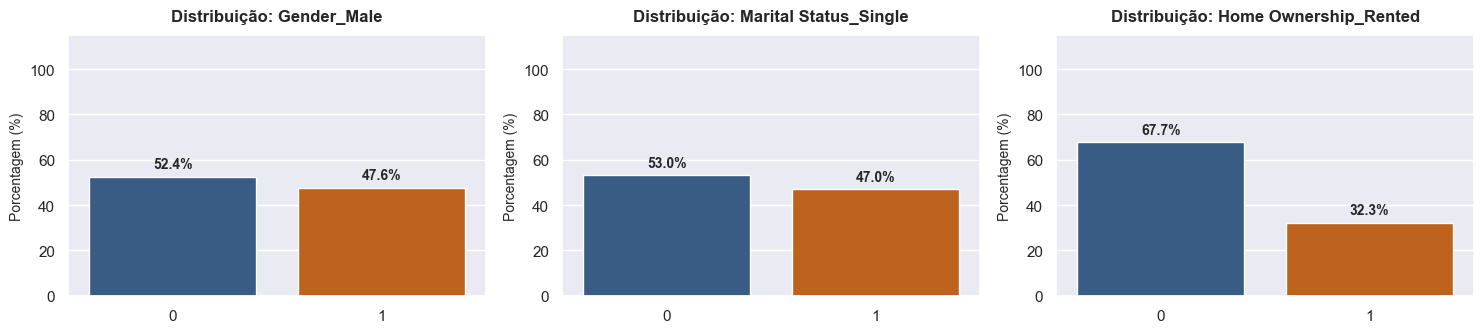

In [46]:
# Filtragem de colunas booleanas da base
colunas_binarias = [col for col in df.columns if df[col].nunique() == 2 and col != 'Age']

# Grade de subgráficos
sns.set_theme(style="darkgrid")
n_cols = 3
n_rows = (len(colunas_binarias) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,3.5 * n_rows))
axes = axes.flatten()

# Itera sobre cada variável e plota as proporções em porcentagem
for i, col in enumerate(colunas_binarias):
    ax = axes[i]

    # Cálculo de porcentagem relativa de cada categoria
    prop = df[col].value_counts(normalize=True) * 100

    # Plot do gráfico de barras
    sns.barplot(x=prop.index, y=prop.values, ax=ax, palette=['#2b5c8f', '#d95f02'])

    ax.set_title(f'Distribuição: {col}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Porcentagem (%)', fontsize=10)
    ax.set_ylim(0,115)

    # Adiciona a porcentagem exata em cima de cada barra
    for p in ax.patches:
        altura = p.get_height()
        ax.annotate(f'{altura:.1f}%',
                    (p.get_x() + p.get_width() / 2, altura),
                    ha='center', va='bottom',
                    xytext=(0, 4),
                    textcoords='offset points',
                    fontsize=10, fontweight='bold',)

# Oculta quadros vazios sobressalentes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**INSIGHT:** Existe uma distribuição equilibrada de homens e mulheres quando se analisa por gênero e também no estado civil entre solteiros e casados. Porém, existe uma distribuição desproporcional entre clientes que possuem imóveis alugados ou próprios, e esse fator pode estar impactando o score de crédito dos clientes de algum desses grupos.

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

A única coluna com outlier detectada, foi a coluna Number of Children, onde o único outlier detectado foi de clientes com 3 filhos. Esse É um dado biologicamente e socialmente plausível, apesar de estatisticamente raro para este grupo específico de dados. Trata-se de um evento de baixa frequência, não de uma anomalia de coleta. Portanto, são registros que devem ser mantidos no modelo, pois podem ensinar o algoritmo a lidar com cenários de maior número de dependentes, a remoção descartaria informações valiosas sobre o comportamento financeiro desse grupo.

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



In [47]:
# Idade e estado civil
fig1 = px.box(
    df,
    x='Marital Status_Single',
    y='Age',
    title='Distribuição de Idade por Estado Civil',
    labels={'Age': 'Idade', 'Marital Status_Single':'Estado Civil (Casado = 0/ Solteiro = 1)'},
    template='plotly_dark'
)

fig1.show()

**Existe relação entre a idade e o status civil?**

É possível observar que quanto maior a idade, maiores as chances do cliente ser casado. Apesar da sobreposição de idades nas duas categorias, a diferença de distribuição é perceptível pelas medianas distintas, pelo deslocamento do intervalo do IQR e pelos limites de idade.

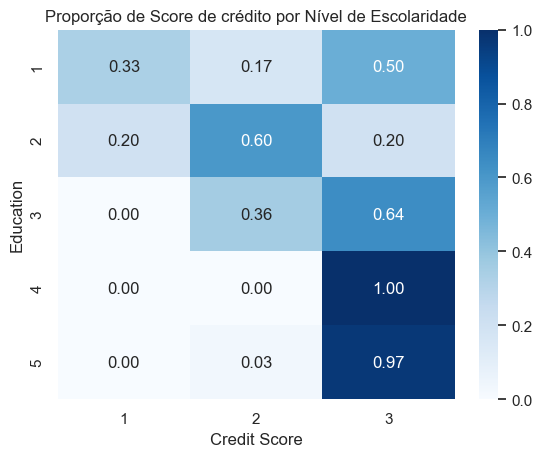

In [48]:
# Score de crédito e nível de escolaridade
tabela_cruzada = pd.crosstab(df['Education'], df['Credit Score'], normalize='index')
sns.heatmap(tabela_cruzada, annot=True, cmap='Blues', fmt='.2f')
plt.title('Proporção de Score de crédito por Nível de Escolaridade')
plt.show()

# LEMBRANDO QUE:
#     'High School Diploma': 1,
#     "Associate's Degree": 2,
#     "Bachelor's Degree": 3,
#     "Master's Degree": 4,
#     'Doctorate': 5

# credit_map = {'Low': 1, 'Average': 2, 'High': 3}

**Qual a relação entre o score de crédito e o nível de escolaridade?**

Quanto maior for o nível de escolaridade, maior será o score de crédito. Essa relação também é proporcional a niveis de escolaridade mais baixos. É possível perceber também que nenhum cliente com nível de escolaridade 3 ou acima tem baixo score de crédito, mas existem distribuições consistentes de clientes com alto score de crédito entre todos os níveis de escolaridade, embora haja variações.

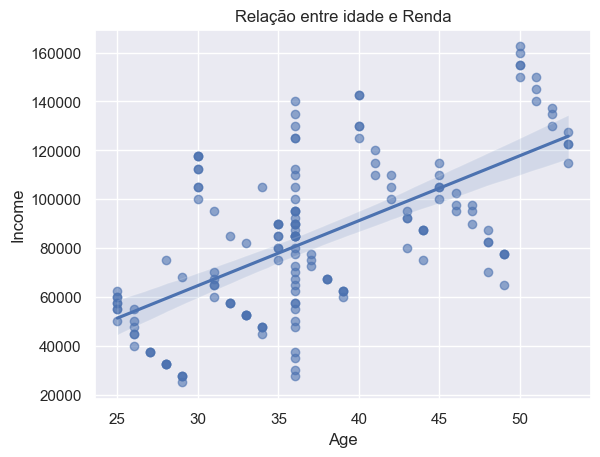

In [49]:
# Salário e idade
sns.regplot(data=df, x='Age', y='Income', scatter_kws={'alpha': 0.6})
plt.title('Relação entre idade e Renda')
plt.show()

**O salário parece influenciar na idade?**

Diante do gráfico, é possível perceber que o crescimento salarial acompanha o avanço da idade. Isso pode significar que os clientes mais 'experientes' com maior grau de escolaridade ou com imóvel próprio acabem por receber mais. Embora também existam exceções, como visto nas dispersões do gráfico.

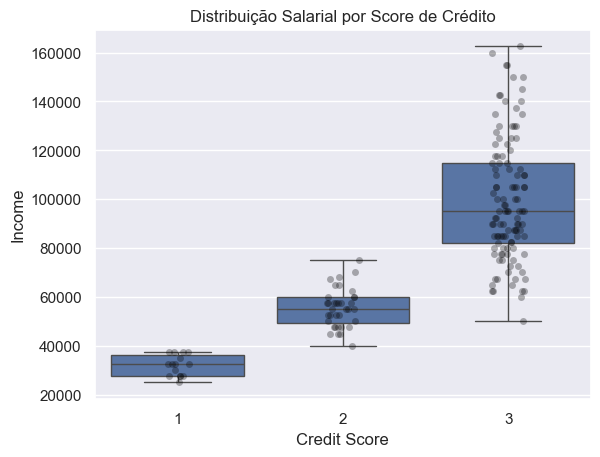

In [50]:
# Salário e Score de Crédito
sns.boxplot(data=df, x='Credit Score', y='Income')
sns.stripplot(data=df, x='Credit Score', y='Income', color='black', alpha=0.3)
plt.title('Distribuição Salarial por Score de Crédito')
plt.show()

**O salário parece influenciar no Score de Crédito?**

Acompanhando o gráfico, é claramente visível que o salário é um fator determinante no score de crédito. O fato de parecer ser um fator determinante, se dá pelo fato de ser visível os valores máximos e mínimos de salário que os clientes distribuídos em cada score de crédito recebem. No entanto, apesar de ser um fator determinante, existem outras variáveis que devem ser levadas em conta além do salário, como visto em insights anteriores.

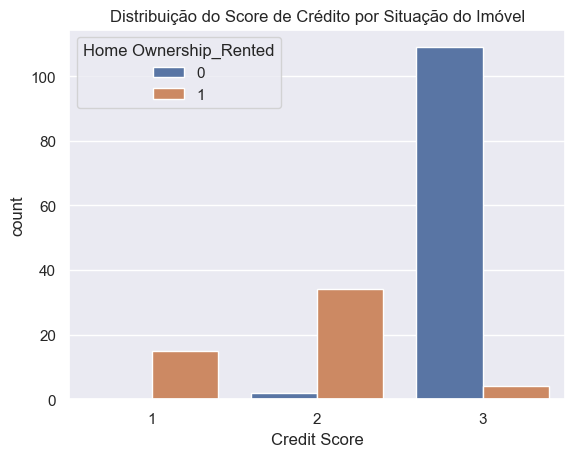

In [51]:
# Situação do imóvel e Score de Crédito
sns.countplot(data=df, x='Credit Score', hue='Home Ownership_Rented')
plt.title('Distribuição do Score de Crédito por Situação do Imóvel')
plt.show()

**Clientes com casa própria tendem a ter um score mais alto?**

Observando o gráfico é possível ver que clientes com casa própria tendem a possuir um score mais alto. Mas o dado mais interessante desse gráfico é o fato de todos os clientes com nível 1 de score de crédito e a esmagadora maioria dos clientes de nível 2 possuem imóvel alugado, sendo a minoria do segundo nível e a esmagadora maioria do nível 3 que possuem casa própria.

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

**A renda é influenciada pelo nível de escolaridade?**

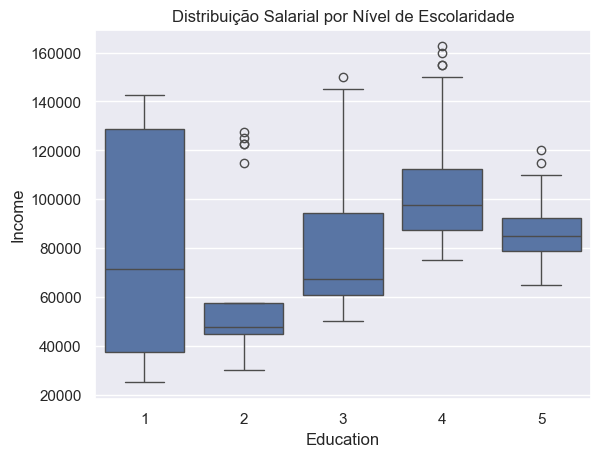

In [52]:
# Education e Income
sns.boxplot(data=df, x='Education', y='Income')
plt.title('Distribuição Salarial por Nível de Escolaridade')
plt.show()

**INSIGHT:** Conforme a escolaridade avança, existe uma tendência direta de elevação da mediana salarial, porém, quando analisado o nível 5, observa-se que a caixa é bastante compacta, indicando baixa variabilidade e renda previsível. Mas quando se compara o nível 5 com o nível 4, percebe-se que a mediana do nível 5 é ligeiramente inferior ao do nível 4, porém, no mercado profissional cargos executivos/corporativos (comuns no nível 4) costumam pagar salários/bônus mais altos do que posições acadêmicas ou de pesquisa sênior (nível 5).

No nível 1, existe a maior variação de todas. Isso indica que a baixa escolaridade formal inclui desde trabalhadores em início de carreira até empreendedores profissionais seniores experientes.

**Existe relação entre a renda e a situação do imóvel?**

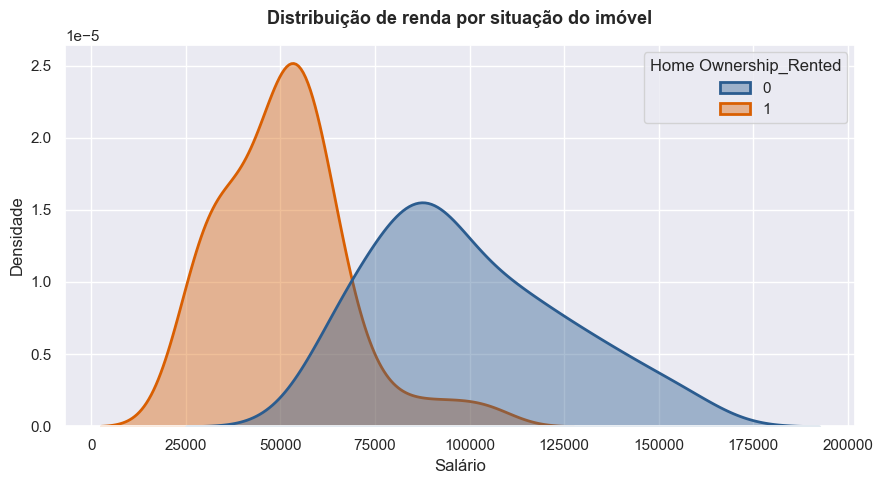

In [53]:
# Home Ownership e Income
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x='Income', hue='Home Ownership_Rented', common_norm=False, fill=True, palette=['#2b5c8f', '#d95f02'], alpha=0.4, linewidth=2)
plt.title('Distribuição de renda por situação do imóvel', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Salário')
plt.ylabel('Densidade')
plt.tight_layout()
plt.show()

**INSIGHT:** Existe uma concentração muito alta de imóveis alugados na faixa de renda menor, se comparado com a concentração de imóveis próprios. A faixa de renda que se aproxima dos 75.000 funciona como um "ponto de virada", ou melhor, a posse do imóvel é um excelente indicador de alta renda acumulada e estabilidade patrimonial.

**O número de filhos tem impacto na renda?**

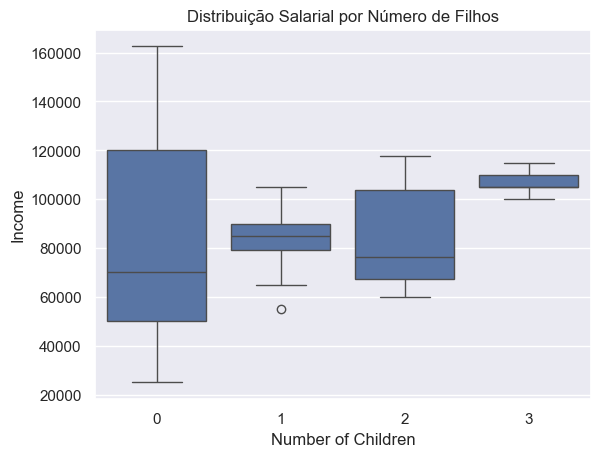

In [54]:
 # Number of Children e Income
sns.boxplot(data=df, x='Number of Children', y='Income')
plt.title('Distribuição Salarial por Número de Filhos')
plt.show()

**INSIGHT:** Nessa base, o grupo que possui 3 filhos é extremamente compacta e posicionada no topo da renda. Na práticam é mostrado que apenas clientes com renda consolidada possuem 3 dependentes.

É observável também que o grupo sem filhos cobre todo o espectro financeiro. Podendo juntar jovens em início da carreira representando baixa renda e também profissionais consolidados sem dependentes.

A distribuição mais equilibrada existe nos grupos que possuem de 1 a 2 dependentes, não há discrepâncias nas medianas em relação à média geral.

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

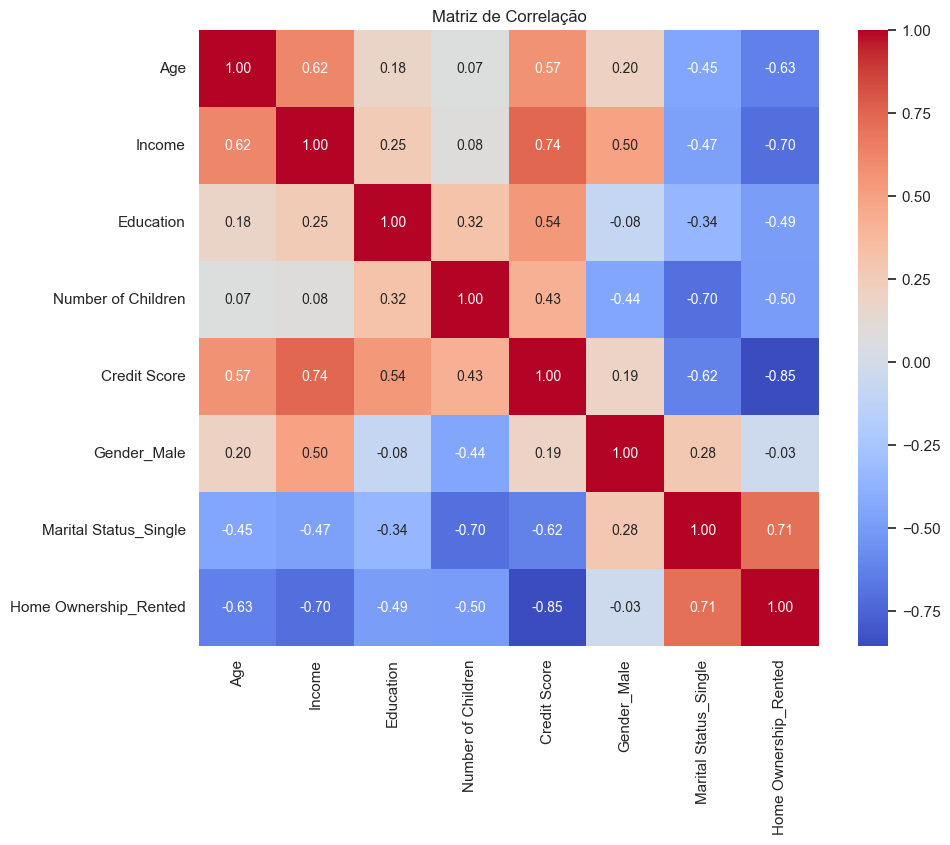

In [55]:
matriz_correlacao = df.select_dtypes(include=['number']).corr()

# Mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={'size': 10})
plt.title('Matriz de Correlação')
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

In [56]:
matriz_correlacao = df.corr(numeric_only=True)

# Pegar apenas a parte superior da matriz para não repetir pares (ex: A-B e B-A)
upper_tri = matriz_correlacao.where(np.triu(np.ones(matriz_correlacao.shape), k=1).astype(bool))

# Empilhar e filtrar pelo limite de 0.6
threshold = 0.60
alta_corr = (
    upper_tri.unstack()
    .dropna()
    .reset_index()
    .rename(columns={'level_0': 'Var_1', 'level_1': 'Var_2', 0: 'Correlacao'})
)

# Filtrar apenas |r| >= 0.60 e ordenar pelo valor absoluto
alta_corr = alta_corr[alta_corr['Correlacao'].abs() >= threshold]
alta_corr = alta_corr.sort_values(by='Correlacao', key=abs, ascending=False)

print("--- PARES COM ALTA CORRELAÇÃO ---")
print(alta_corr.to_string(index=False))

--- PARES COM ALTA CORRELAÇÃO ---
                Var_1                 Var_2  Correlacao
Home Ownership_Rented          Credit Score   -0.854970
         Credit Score                Income    0.744407
Home Ownership_Rented Marital Status_Single    0.708374
Home Ownership_Rented                Income   -0.704928
Marital Status_Single    Number of Children   -0.696984
Home Ownership_Rented                   Age   -0.628042
               Income                   Age    0.621492
Marital Status_Single          Credit Score   -0.619854


As correlações fazem sentido. Elas refletem de forma coerente o ciclo de vida socioeconômico e a maturação financeira dos clientes.

A cadeia de relações é guiada pelo avanço da idade e da escolaridade, que proporcionam maior senioridade profissional e impulsionam o crescimento da renda. Esse ganho do poder aquisitivo viabiliza o acúmulo de patrimônio, permitindo a transição do aluguem para a aquisição de um imóvel próprio. Paralelamente o momento de vida influencia a estrutura familiar: clientes mais velhos e casados tendem a buscar estabilidade residencial e a ter mais filhos.

Os fatores de estabilidade financeira e patrimonial convergem no score de crédito: clientes de maior renda e com imóvel próprio apresentam menor risco de inadimplência, justificando a forte associação positiva com o salário, e a forte associação negativa com a condição do aluguel.

In [57]:
# Tratando multicolinearidade
def remover_multicolinearidade(dataframe, limite=0.80):
    """
    Identifica e remove colunas com correlação acima do limite especificado
    """
    corr_abs = dataframe.corr(numeric_only=True).abs()
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

    # Lista de colunas para descartar
    colunas_para_remover = [coluna for coluna in upper.columns if any(upper[coluna] > limite)]

    df_filtrado = dataframe.drop(columns=colunas_para_remover)
    return df_filtrado, colunas_para_remover

df_modelo, descartadas = remover_multicolinearidade(df, limite=0.80)

print(f"Colunas removidas por alta redundância: {descartadas}")
print(f"Novo formato da base: {df_modelo.shape}")

Colunas removidas por alta redundância: ['Home Ownership_Rented']
Novo formato da base: (164, 7)


**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

*Procedimento já realizado na etapa 1 - A*

**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

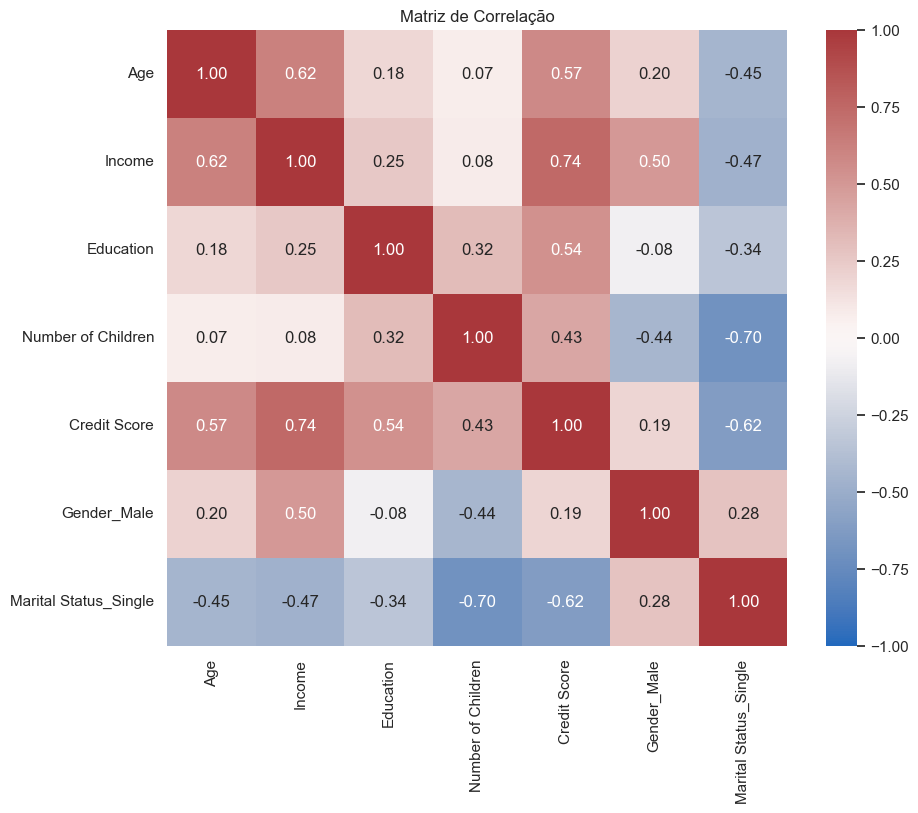

In [58]:
# Heatmap após tratamentos
plt.figure(figsize=(10, 8))
sns.heatmap(df_modelo.corr(numeric_only=True), annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Matriz de Correlação')
plt.show()

Após tratamento, não há mais variáveis com forte correlação a ponto de existir multicolinearidade.

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [59]:
# Separando as variáveis preditoras e a variável alvo
x = df.drop(columns=['Credit Score'])
y = df['Credit Score']

# Divisão em 75% para treino e 25% para teste (com stratify para manter a proporção das classes)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

# Verificando
print(f'X_train shape: {x_train.shape}')
print(f'X_test shape:  {x_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape:  {y_test.shape}')

X_train shape: (123, 7)
X_test shape:  (41, 7)
y_train shape: (123,)
y_test shape:  (41,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

C:\Users\Windows\AppData\Local\Temp\ipykernel_9816\973638230.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


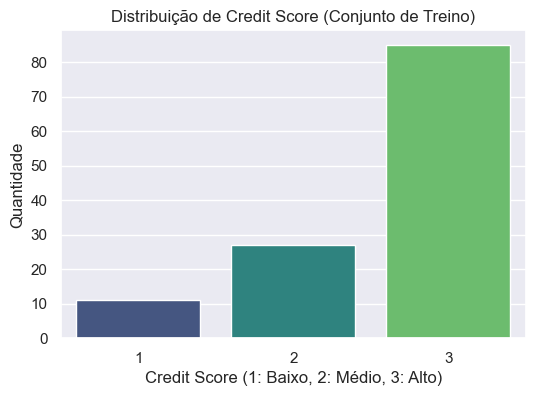

In [60]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette='viridis')
plt.title('Distribuição de Credit Score (Conjunto de Treino)')
plt.xlabel('Credit Score (1: Baixo, 2: Médio, 3: Alto)')
plt.ylabel('Quantidade')
plt.show()

Existe desbalanceamento na distribuição das colunas Credit Score. A quantidade presente nos respectivos níveis de score de crédito é desproporcional, existindo uma quantidade muito grande no nível 3 se comparado com os demais níveis. E mesmo que os níveis 1 e 2 estejam mais próximos, ainda está desbalanceado.

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

Antes do balanceamento (y_train):
Credit Score
3    85
2    27
1    11
Name: count, dtype: int64

Depois do balanceamento (y_train_bal):
Credit Score
2    85
3    85
1    85
Name: count, dtype: int64


C:\Users\Windows\AppData\Local\Temp\ipykernel_9816\480467648.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_bal, palette='viridis')


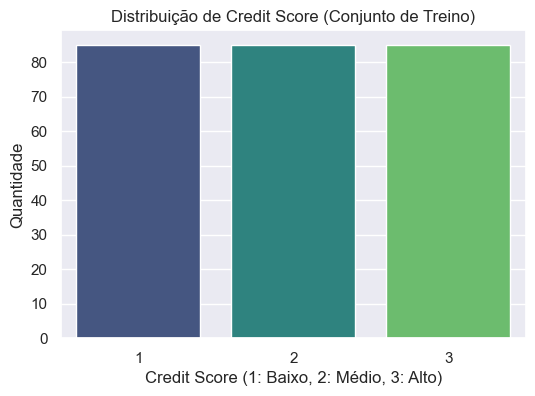

In [61]:
# Utilizando o SMOTE
smote = SMOTE(random_state=42)

# Aplicando o balanceamento apenas nos dados do treino
x_train_bal, y_train_bal = smote.fit_resample(x_train, y_train)

# Verificando a nova contagem de classes
print("Antes do balanceamento (y_train):")
print(y_train.value_counts())

print("\nDepois do balanceamento (y_train_bal):")
print(pd.Series(y_train_bal).value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_bal, palette='viridis')
plt.title('Distribuição de Credit Score (Conjunto de Treino)')
plt.xlabel('Credit Score (1: Baixo, 2: Médio, 3: Alto)')
plt.ylabel('Quantidade')
plt.show()